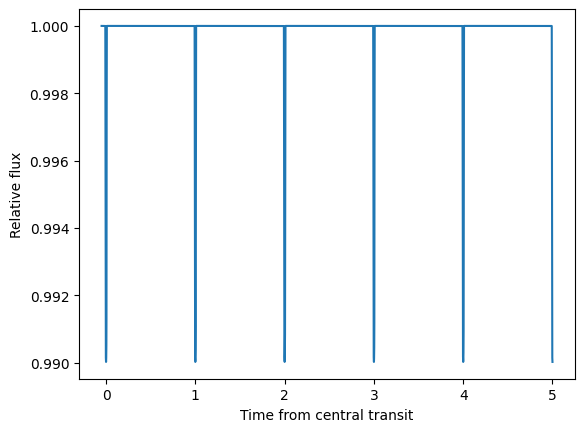

In [6]:
import batman
import numpy as np
import matplotlib.pyplot as plt


params = batman.TransitParams()
params.t0 = 0.                       #time of inferior conjunction
params.per = 1.                      #orbital period
params.rp = 0.1                      #planet radius (in units of stellar radii)
params.a = 15.                       #semi-major axis (in units of stellar radii)
params.inc = 87.                     #orbital inclination (in degrees)
params.ecc = 0.                      #eccentricity
params.w = 90.                       #longitude of periastron (in degrees)
params.u = [0.1, 0.3]                #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model


t = np.linspace(-0.05, 5, 1000000)


m = batman.TransitModel(params, t)    #initializes model
flux = m.light_curve(params)          #calculates light curve


plt.plot(t, flux)
plt.xlabel("Time from central transit")
plt.ylabel("Relative flux")
plt.show()

In [ ]:
phase_lag =
t_0 = period*(phase_lag + np.pi/2)/(2*np.pi)

In [7]:
params = batman.TransitParams()
params.t0 = 0.5                       #time of inferior conjunction
params.per = 1.                      #orbital period
params.rp = 0.1                      #planet radius (in units of stellar radii)
params.a = 15.                       #semi-major axis (in units of stellar radii)
params.inc = 87.                     #orbital inclination (in degrees)
params.ecc = 0.                      #eccentricity
params.w = 90.                       #longitude of periastron (in degrees)
params.u = [0.1, 0.3]                #limb darkening coefficients [u1, u2]
params.limb_dark = "quadratic"       #limb darkening model

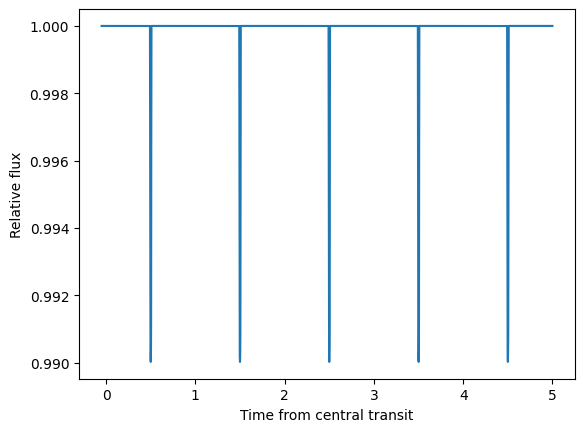

In [8]:
t = np.linspace(-0.05, 5, 1000000)


m = batman.TransitModel(params, t)    #initializes model
flux = m.light_curve(params)          #calculates light curve


plt.plot(t, flux)
plt.xlabel("Time from central transit")
plt.ylabel("Relative flux")
plt.show()

In [9]:
bob = ["bob","jim","joe"]

for i in enumerate(bob):
    print(i)

(0, 'bob')
(1, 'jim')
(2, 'joe')


In [ ]:
[eta, a, p, e, inc, omega, big_ohm, phase_lag, mass (only for N body)]

In [ ]:
radius_toi_1181 = 1.961 * 696.34e6 / 1.496e11
mass_toi_1181 = 1.467 * 2e30 / 6e24
limb_darkening_model = "quadratic"
limb_darkening_coefficients = [0.295, 0.312]

stellar_params = [radius_toi_1181, mass_toi_1181, limb_darkening_model, limb_darkening_coefficients]  # Based on WASP 148


In [35]:
def use_batman(planet_params, stellar_params, times):
    import batman
    flux = np.zeros(len(times))
    stellar_radius, stellar_mass, limb_darkening_model, limb_darkening_coefficients = stellar_params

    for planet_param in planet_params:
        a = planet_param[1] * 1.496e11 / stellar_radius
        t_0 = planet_param[2]*(planet_param[7] + np.pi/2)/(2*np.pi)

        params = batman.TransitParams()
        params.t0 = t_0                       #time of inferior conjunction
        params.per = planet_param[2]                      #orbital period
        params.rp = planet_param[0]                     #planet radius (in units of stellar radii)
        params.a = a                   #semi-major axis (in units of stellar radii)
        params.inc = np.degrees(planet_param[4])                     #orbital inclination (in degrees)
        params.ecc = planet_param[3]                      #eccentricity
        params.w = planet_param[5]                       #longitude of periastron (in degrees)
        params.u = limb_darkening_coefficients                #limb darkening coefficients [u1, u2]
        params.limb_dark = limb_darkening_model       #limb darkening model

        m = batman.TransitModel(params, times)    #initializes model
        flux += m.light_curve(params) - 1         #calculates light curve
        plt.plot(times, m.light_curve(params))
        plt.show()

    flux += 1
    plt.plot(times, flux)
    plt.xlabel("Time from central transit")
    plt.ylabel("Relative flux")
    plt.show()
    return flux


In [42]:
# Stellar parameters: [radius, mass]
radius_toi_1181 = 1.961 * 696.34e6
mass_toi_1181 = 1.467 * 2e30 / 6e24
limb_darkening_model = "quadratic"
limb_darkening_coefficients = [0.295, 0.312]

stellar_params = [radius_toi_1181, mass_toi_1181, limb_darkening_model, limb_darkening_coefficients]  # Based on WASP 148

eta1 = 0.3
eta2 = 0.4
# planet_params =[ [ eta,   a,     P,   e,               inc, omega, OHM, phase_lag ] ]
planet_params = np.array(
    [
        [eta1, 0.08215, 8.803809, 0, np.radians(90), 0, 0, -np.pi/2, 0.287],
        [eta2, 0.2044, 34.525, 0, np.radians(90), 0, 0, np.pi / 4, 0.392]
    ]
)

In [43]:
num_samples = 60000
number_max_period = 4
times_input = np.linspace(0, 4 * 34, 60000)  # Three orbital periods for planet 1


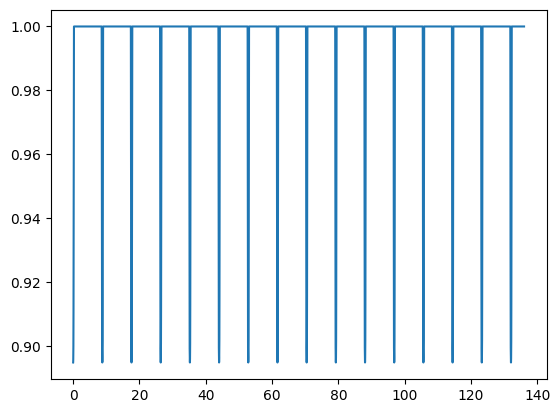

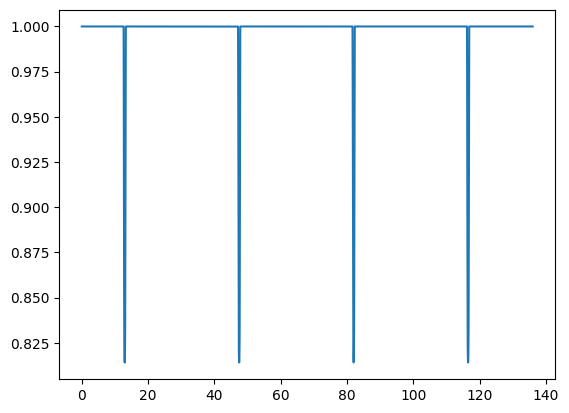

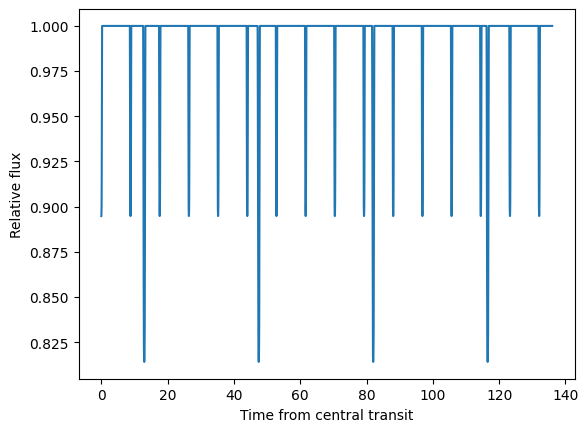

In [44]:
flux = use_batman(planet_params, stellar_params, times_input)